In [8]:
# Session 13
import pandas as pd

In [9]:
df = pd.read_csv("/Users/avirajsingh/perovskites_data.csv")

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
  Material_ID Formula  Band_Gap  Formation_Energy_Per_Atom     Volume
0  mp-1183115  AcAlO3    4.1024                  -3.690019  57.451413
1  mp-1183052   AcBO3    0.8071                  -2.475390  51.548126
2   mp-866101  AcCrO3    2.0031                  -3.138972  61.362845
3   mp-864606  AcCuO3    0.0000                  -2.422892  59.929387
4   mp-861502  AcFeO3    1.0084                  -2.771539  61.797311


In [10]:
import matplotlib.pyplot as plt

In [11]:
import seaborn as sns

In [12]:
import scipy.stats as stats

In [15]:
df = pd.read_csv("perovskites_data.csv")

In [17]:
print(f"Initial row count: {len(df)}")

Initial row count: 4719


In [18]:
# Rename columns to standard schema (formula, T, Cp)[cite: 16]
df = df.rename(columns={'Formula': 'formula', 'Temperature': 'T', 'Heat_Capacity': 'Cp'})

In [19]:
count_before_dropna = len(df)

In [22]:
print(df.columns.tolist())

['Material_ID', 'formula', 'Band_Gap', 'Formation_Energy_Per_Atom', 'Volume']


In [23]:
print(df.head())

  Material_ID formula  Band_Gap  Formation_Energy_Per_Atom     Volume
0  mp-1183115  AcAlO3    4.1024                  -3.690019  57.451413
1  mp-1183052   AcBO3    0.8071                  -2.475390  51.548126
2   mp-866101  AcCrO3    2.0031                  -3.138972  61.362845
3   mp-864606  AcCuO3    0.0000                  -2.422892  59.929387
4   mp-861502  AcFeO3    1.0084                  -2.771539  61.797311


In [24]:
print(f"Rows dropped due to NaN: {count_before_dropna - len(df)}")

Rows dropped due to NaN: 0


In [26]:
valid_mask = df['Band_Gap'] >= 0
df = df[valid_mask]

print("Valid rows:", len(df))

Valid rows: 4719


In [28]:
dropped_unphysical = (~valid_mask).sum()

In [29]:
df_clean = df[valid_mask].copy()

In [30]:
print(f"Rows dropped due to unphysical values (T < 0 or Cp < 0): {dropped_unphysical}")

Rows dropped due to unphysical values (T < 0 or Cp < 0): 0


In [31]:
print(f"Final cleaned dataset row count: {len(df_clean)}")

Final cleaned dataset row count: 4719


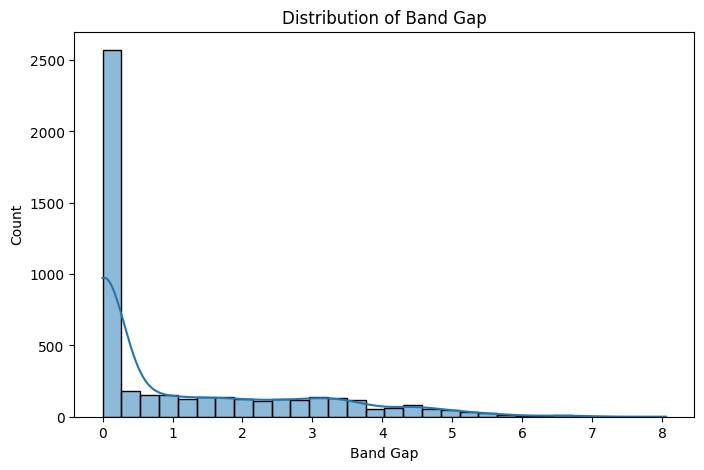

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(df_clean['Band_Gap'], kde=True, bins=30)

plt.title('Distribution of Band Gap')
plt.xlabel('Band Gap')
plt.ylabel('Count')

plt.show()

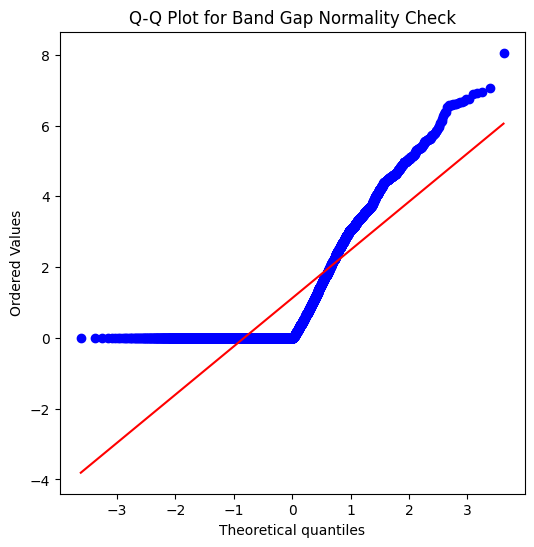

In [35]:
# 6. Perform a Q-Q normality check
plt.figure(figsize=(6,6))

stats.probplot(df_clean['Band_Gap'], dist="norm", plot=plt)

plt.title('Q-Q Plot for Band Gap Normality Check')
plt.show()

In [36]:
# Save the cleaned dataset deliverable
df_clean.to_csv('cleaned_cp_dataset.csv', index=False)
print("✅ Cleaned Cp dataset successfully saved and ready for commit.")

✅ Cleaned Cp dataset successfully saved and ready for commit.


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
df = pd.read_csv('cleaned_cp_dataset.csv')

In [39]:
sample_materials = df['formula'].unique()[:5]

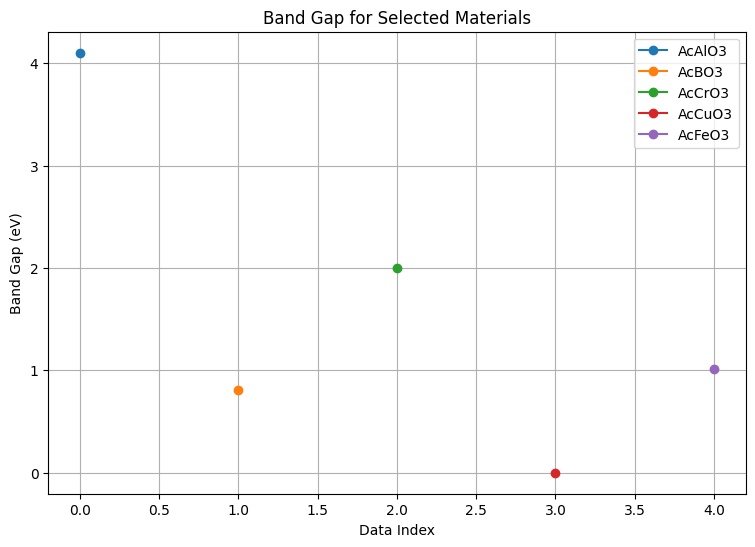

In [41]:
plt.figure(figsize=(9, 6))

for mat in sample_materials:
    subset = df[df['formula'] == mat]
    plt.plot(subset.index, subset['Band_Gap'], marker='o', label=mat)

plt.title('Band Gap for Selected Materials')
plt.xlabel('Data Index')
plt.ylabel('Band Gap (eV)')
plt.legend()
plt.grid(True)
plt.show()

In [42]:
def classify_family(formula):
    if 'O' in formula and 'C' not in formula and 'N' not in formula:
        return 'Oxide'
    elif 'C' in formula:
        return 'Carbide'
    elif 'N' in formula:
        return 'Nitride'
    else:
        return 'Other'

In [43]:
df['family'] = df['formula'].apply(classify_family)
df_grouped = df[df['family'].isin(['Oxide', 'Carbide', 'Nitride'])]

In [45]:
family_stats = df_grouped.groupby('formula')['Band_Gap'].agg(['mean', 'std']).reset_index()

print(family_stats)

     formula     mean       std
0     AcAlO3  4.10240       NaN
1      AcBO3  0.80710       NaN
2     AcCrO3  2.00310       NaN
3     AcCuO3  0.00000       NaN
4     AcFeO3  1.00840       NaN
...      ...      ...       ...
2272  ZrSiO3  0.00000       NaN
2273  ZrTiO3  0.00000       NaN
2274  ZrTlO3  0.00000       NaN
2275   ZrWN3  0.00000       NaN
2276  ZrZnO3  2.27005  3.210335

[2277 rows x 3 columns]


In [46]:
print("✅ Chemical family grouping and statistical aggregation complete.")

✅ Chemical family grouping and statistical aggregation complete.
